#1. Loading and preping the data

In [ ]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
import tensorflow as tf

In [ ]:
print(tf.__version__)

2.2.0


In [ ]:

!pip install -q git+https://github.com/tensorflow/docs


In [ ]:
import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling


Loading the MPG Dataset

In [90]:
#downloading the dataset
dataset_path = tf.keras.utils.get_file("auto-mpg.data", "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")
dataset_path


'/root/.keras/datasets/auto-mpg.data'

In [91]:
column_names = ['MPG', 'Cylinders', 'Displacment', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Orgin']
dataset = pd.read_csv(dataset_path, names=column_names,
                     na_values="?" , comment='\t',
                      sep=" ", skipinitialspace=True)
dataset.tail()

,MPG,Cylinders,Displacment,Horsepower,Weight,Acceleration,Model Year,Orgin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [92]:
#cleaning the data
dataset.isna().sum()

MPG             0
Cylinders       0
Displacment     0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Orgin           0
dtype: int64

#2. Preprocessing the Data

In [93]:
dataset = dataset.dropna()

In [94]:
#Converting the orgin to countries
dataset['Orgin'] = dataset['Orgin'].map({1:'USA', 2:'Europe', 3:'Japan'})

In [95]:
dataset = pd.get_dummies(dataset, prefix='', prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacment,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,0,0,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,1,0,0
395,32.0,4,135.0,84.0,2295.0,11.6,82,0,0,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,0,0,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,0,0,1


#3. Train Test Split

In [96]:
from sklearn.model_selection import  train_test_split


In [97]:
X = dataset.drop('MPG', axis=1)

In [98]:
y = dataset['MPG']

In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

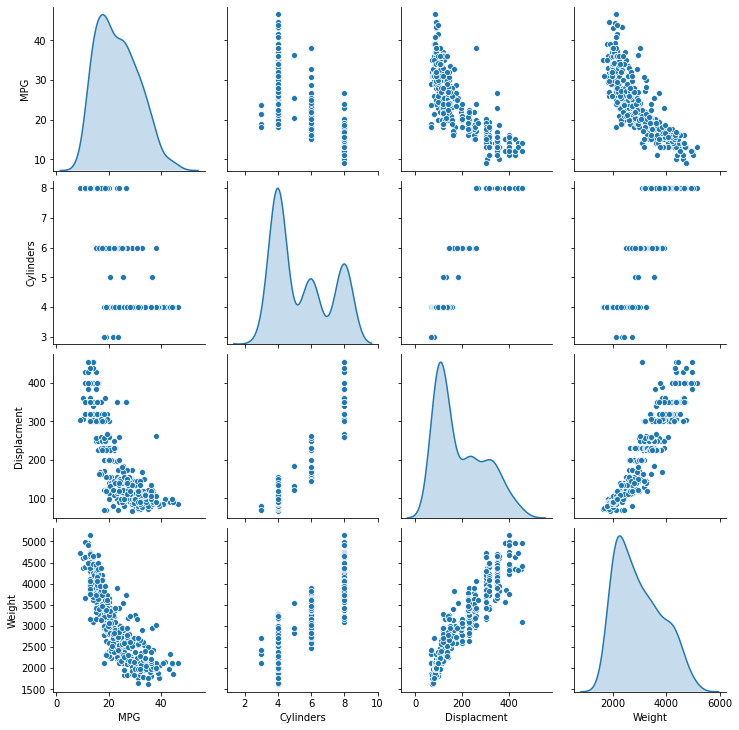

In [100]:
sns.pairplot(dataset[["MPG", "Cylinders", "Displacment", "Weight"]], 
             diag_kind="kde")

In [101]:
dataset.drop('MPG', axis=1).describe()

,Cylinders,Displacment,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,0.173469,0.201531,0.625000
std,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.379136,0.401656,0.484742
min,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,0.000000,0.000000,0.000000
25%,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,0.000000,0.000000,0.000000
50%,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,0.000000,0.000000,1.000000
75%,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,0.000000,0.000000,1.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,1.000000,1.000000,1.000000


In [102]:
X_train.describe()

,Cylinders,Displacment,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
count,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000,313.000000
mean,5.482428,195.517572,104.594249,2986.124601,15.544089,76.207668,0.153355,0.201278,0.645367
std,1.700446,103.766567,38.283669,841.133957,2.817864,3.630136,0.360906,0.401597,0.479168
min,3.000000,70.000000,46.000000,1613.000000,8.000000,70.000000,0.000000,0.000000,0.000000
25%,4.000000,105.000000,76.000000,2234.000000,13.500000,73.000000,0.000000,0.000000,0.000000
50%,4.000000,151.000000,95.000000,2855.000000,15.500000,76.000000,0.000000,0.000000,1.000000
75%,8.000000,302.000000,129.000000,3645.000000,17.300000,79.000000,0.000000,0.000000,1.000000
max,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,1.000000,1.000000,1.000000


#4. Feature Scaling

In [103]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [104]:
X_test = scaler.transform(X_test)

#5. Building the model

In [119]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [120]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=[X_train.shape[1]]))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))


In [121]:
optimizer = tf.keras.optimizers.RMSprop(0.001)
model.compile(loss='mse',
              optimizer=optimizer,
              metrics=['mae', 'mse', tf.keras.metrics.MeanSquaredError()])

In [122]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_6 (Dense)              (None, 64)                640       
_________________________________________________________________
dense_7 (Dense)              (None, 64)                4160      
_________________________________________________________________
dense_8 (Dense)              (None, 1)                 65        
Total params: 4,865
Trainable params: 4,865
Non-trainable params: 0
_________________________________________________________________


#6. Training the model

In [123]:
history = model.fit(
    X_train, y_train,
    epochs=1000, validation_split = 0.2,
    callbacks=([tfdocs.modeling.EpochDots()])
)

Epoch 1/1000
1/8 [==>...........................] - ETA: 0s - loss: 670.5995 - mae: 24.9401 - mse: 670.5995 - mean_squared_error: 670.5995
Epoch: 0, loss:575.8094,  mae:22.6095,  mean_squared_error:575.8094,  mse:575.8094,  val_loss:623.0212,  val_mae:23.6574,  val_mean_squared_error:623.0212,  val_mse:623.0212,  
8/8 [==============================] - 0s 18ms/step - loss: 575.8094 - mae: 22.6095 - mse: 575.8094 - mean_squared_error: 575.8094 - val_loss: 623.0212 - val_mae: 23.6574 - val_mse: 623.0212 - val_mean_squared_error: 623.0212
Epoch 2/1000
8/8 [==============================] - 0s 6ms/step - loss: 521.5645 - mae: 21.3529 - mse: 521.5645 - mean_squared_error: 521.5645 - val_loss: 567.4896 - val_mae: 22.4558 - val_mse: 567.4896 - val_mean_squared_error: 567.4896
Epoch 3/1000
8/8 [==============================] - 0s 6ms/step - loss: 469.6219 - mae: 20.0821 - mse: 469.6219 - mean_squared_error: 469.6219 - val_loss: 509.4315 - val_mae: 21.1271 - val_mse: 509.4315 - val_mean_square

#7 Evaluating the model

In [124]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()


,loss,mae,mse,mean_squared_error,val_loss,val_mae,val_mse,val_mean_squared_error,epoch
995,3.393971,1.188820,3.393971,3.393971,6.664319,1.841255,6.664319,6.664319,995
996,3.167308,1.133880,3.167308,3.167308,7.324818,1.914182,7.324818,7.324818,996
997,3.273472,1.163433,3.273472,3.273472,7.431767,1.911465,7.431767,7.431767,997
998,3.324072,1.140089,3.324072,3.324072,6.582397,1.773330,6.582397,6.582397,998
999,3.246309,1.172859,3.246309,3.246309,8.028005,2.034655,8.028005,8.028005,999


In [125]:
plotter = tfdocs.plots.HistoryPlotter(smoothing_std=2)


Text(0, 0.5, 'MAE [MPG]')

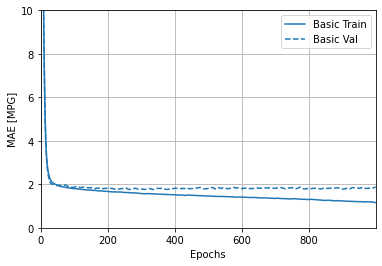

In [126]:
plotter.plot({'Basic': history}, metric = "mae")
plt.ylim([0, 10])
plt.ylabel('MAE [MPG]')


Text(0, 0.5, 'MSE [MPG^2]')

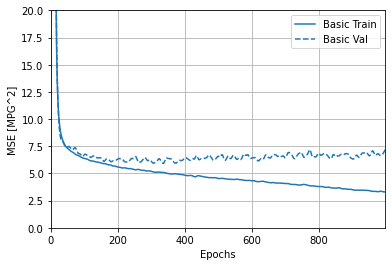

In [127]:
plotter.plot({'Basic': history}, metric = "mse")
plt.ylim([0, 20])
plt.ylabel('MSE [MPG^2]')


#8. Early stopping

In [128]:
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

early_history = model.fit(X_train, y_train, 
                    epochs=1000, validation_split = 0.2, verbose=0, 
                    callbacks=[early_stop, tfdocs.modeling.EpochDots()])


Epoch: 0, loss:3.3066,  mae:1.1787,  mean_squared_error:3.3066,  mse:3.3066,  val_loss:7.3880,  val_mae:1.8799,  val_mean_squared_error:7.3880,  val_mse:7.3880,  
...................

Text(0, 0.5, 'MAE [MPG]')

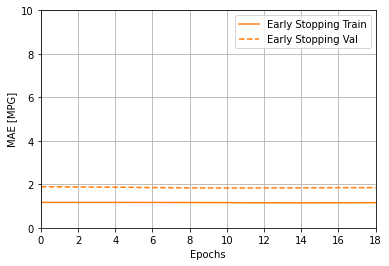

In [129]:
plotter.plot({'Early Stopping': early_history}, metric = "mae")
plt.ylim([0, 10])
plt.ylabel('MAE [MPG]')

In [130]:
loss, mae, mse, rmse = model.evaluate(X_test, y_test, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))
print("Testing set Mean squared Error: {:5.2f} MPG".format(mse))
print("Testing set Mean root mean squared Error: {:5.2f} MPG".format(rmse))



3/3 - 0s - loss: 6.8847 - mae: 1.9401 - mse: 6.8847 - mean_squared_error: 6.8847
Testing set Mean Abs Error:  1.94 MPG
Testing set Mean squared Error:  6.88 MPG
Testing set Mean root mean squared Error:  6.88 MPG


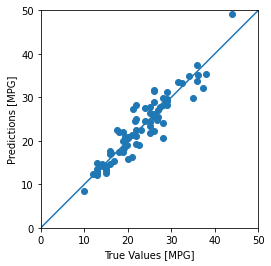

In [131]:
test_predictions = model.predict(X_test).flatten()

a = plt.axes(aspect='equal')
plt.scatter(y_test, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)



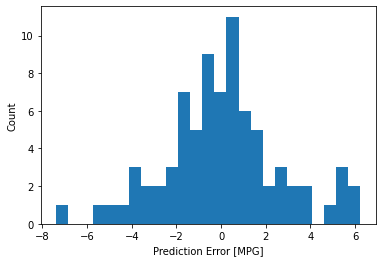

In [132]:
error = test_predictions - y_test
plt.hist(error, bins = 25)
plt.xlabel("Prediction Error [MPG]")
_ = plt.ylabel("Count")
